# GSoC 2026 — NeuroDyads Pre-Task
## Brain-to-Brain Decoder: Validating Neural Synchrony Patterns
**Applicant:** Deepak Gupta | IIT Jammu | guptadeepak46474@gmail.com  
**Organization:** ML4SCI | Mentors: Dr. Evie Malaia & Dr. Brendan Ames 

## Setup & Installations


In [2]:
# Install required packages if not already installed
import subprocess
subprocess.run(['pip', 'install', 'mne', 'cebra', 'scikit-learn', 'matplotlib',
                'numpy', 'scipy', 'torch', 'pyedflib'], capture_output=True)
print('Packages ready.')

Packages ready.


In [3]:
import mne
import numpy as np
import matplotlib
matplotlib.use('Agg')  # use if running headless; remove for interactive
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import cebra
import torch
import warnings
warnings.filterwarnings('ignore')

mne.set_log_level('WARNING')
print('MNE version:', mne.__version__)
print('CEBRA version:', cebra.__version__)
print('All imports successful.')

MNE version: 1.11.0
CEBRA version: 0.6.0
All imports successful.


---
## Part 1: Preprocessing

### 1.1 Load Raw EDF Files

Update the file paths below to point to the two EDF files you downloaded.

In [4]:
# I downloaded both EDF files from the Alabama Box link and set paths here
FILE_A = '/content/Listener.edf'   # path to participant A's EDF file
FILE_B = '/content/Speaker.edf'   # path to participant B's EDF file

# Loading both participant files
raw_A = mne.io.read_raw_edf(FILE_A, preload=True)
raw_B = mne.io.read_raw_edf(FILE_B, preload=True)

print('Participant A:')
print(f'  Channels: {len(raw_A.ch_names)}, Sfreq: {raw_A.info["sfreq"]} Hz')
print(f'  Duration: {raw_A.times[-1]:.1f} sec')
print()
print('Participant B:')
print(f'  Channels: {len(raw_B.ch_names)}, Sfreq: {raw_B.info["sfreq"]} Hz')
print(f'  Duration: {raw_B.times[-1]:.1f} sec')
print()
print('Channel names (A):', raw_A.ch_names)

Participant A:
  Channels: 65, Sfreq: 250.0 Hz
  Duration: 303.0 sec

Participant B:
  Channels: 65, Sfreq: 250.0 Hz
  Duration: 303.0 sec

Channel names (A): ['EEG 1', 'EEG 2', 'EEG 3', 'EEG 4', 'EEG 5', 'EEG 6', 'EEG 7', 'EEG 8', 'EEG 9', 'EEG 10', 'EEG 11', 'EEG 12', 'EEG 13', 'EEG 14', 'EEG 15', 'EEG 16', 'EEG 17', 'EEG 18', 'EEG 19', 'EEG 20', 'EEG 21', 'EEG 22', 'EEG 23', 'EEG 24', 'EEG 25', 'EEG 26', 'EEG 27', 'EEG 28', 'EEG 29', 'EEG 30', 'EEG 31', 'EEG 32', 'EEG 33', 'EEG 34', 'EEG 35', 'EEG 36', 'EEG 37', 'EEG 38', 'EEG 39', 'EEG 40', 'EEG 41', 'EEG 42', 'EEG 43', 'EEG 44', 'EEG 45', 'EEG 46', 'EEG 47', 'EEG 48', 'EEG 49', 'EEG 50', 'EEG 51', 'EEG 52', 'EEG 53', 'EEG 54', 'EEG 55', 'EEG 56', 'EEG 57', 'EEG 58', 'EEG 59', 'EEG 60', 'EEG 61', 'EEG 62', 'EEG 63', 'EEG 64', 'EEG VREF']


### 1.2 Segmentation — Crop Using DIN1 Markers

**Decision rationale:** The data contains three DIN1 markers. We segment:
- **Positive affect segment:** DIN1 marker 1 → DIN1 marker 2
- **Negative affect segment:** DIN1 marker 3 → end of file

This segmentation is critical because CEBRA learns structure from temporal alignment. If both participants are not cropped to identical time windows, the joint neural activity will not be time-locked and any embedding structure would be artifactual — not reflecting real brain-to-brain synchrony.

In [5]:
def get_din1_times(raw):
    """Extract onset times of all DIN1 events from annotations."""
    din1_times = []
    for ann in raw.annotations:
        # DIN1 markers may appear as 'DIN1', 'DIN 1', 'DOUT1', etc.
        # Inspect raw.annotations to see exact label names
        if 'DIN1' in ann['description'].upper() or 'DIN1' in ann['description']:
            din1_times.append(ann['onset'])
    return sorted(din1_times)

# First I checked what the marker labels look like in this specific dataset
print('Annotations in file A:')
for ann in raw_A.annotations:
    print(f'  {ann["description"]:20s}  onset={ann["onset"]:.2f}s')

print()
print('Annotations in file B:')
for ann in raw_B.annotations:
    print(f'  {ann["description"]:20s}  onset={ann["onset"]:.2f}s')

Annotations in file A:
  DIN1                  onset=1.00s
  DIN1                  onset=148.78s
  DIN1                  onset=149.05s

Annotations in file B:
  VBeg                  onset=0.71s
  DIN1                  onset=0.79s
  DIN1                  onset=148.56s
  DIN1                  onset=148.84s
  VEnd                  onset=302.43s


In [6]:
# Confirmed DIN1 is the correct marker name from the annotation output above
MARKER_NAME = 'DIN1'   # change if your file uses a different label

def get_marker_times(raw, marker_name):
    times = [ann['onset'] for ann in raw.annotations
             if marker_name in ann['description']]
    return sorted(times)

markers_A = get_marker_times(raw_A, MARKER_NAME)
markers_B = get_marker_times(raw_B, MARKER_NAME)

print(f'DIN1 marker times in A: {markers_A}')
print(f'DIN1 marker times in B: {markers_B}')

assert len(markers_A) >= 3, 'Expected at least 3 DIN1 markers in file A'
assert len(markers_B) >= 3, 'Expected at least 3 DIN1 markers in file B'

# Positive affect: marker1 → marker2
pos_start = markers_A[0]
pos_end   = markers_A[1]

# Negative affect: marker3 → end
neg_start = markers_A[2]
neg_end   = raw_A.times[-1]

print(f'\nPositive affect segment: {pos_start:.2f}s → {pos_end:.2f}s  (duration: {pos_end - pos_start:.1f}s)')
print(f'Negative affect segment: {neg_start:.2f}s → {neg_end:.2f}s  (duration: {neg_end - neg_start:.1f}s)')

DIN1 marker times in A: [np.float64(1.005), np.float64(148.778), np.float64(149.052)]
DIN1 marker times in B: [np.float64(0.788), np.float64(148.561), np.float64(148.835)]

Positive affect segment: 1.00s → 148.78s  (duration: 147.8s)
Negative affect segment: 149.05s → 303.00s  (duration: 153.9s)


In [7]:
# Cropping both participants to the same time windows so they stay time-locked
raw_A_pos = raw_A.copy().crop(tmin=pos_start, tmax=pos_end)
raw_B_pos = raw_B.copy().crop(tmin=pos_start, tmax=pos_end)

raw_A_neg = raw_A.copy().crop(tmin=neg_start, tmax=neg_end)
raw_B_neg = raw_B.copy().crop(tmin=neg_start, tmax=neg_end)

print('Positive segment shapes:')
print(f'  A: {raw_A_pos.get_data().shape}, B: {raw_B_pos.get_data().shape}')
print('Negative segment shapes:')
print(f'  A: {raw_A_neg.get_data().shape}, B: {raw_B_neg.get_data().shape}')

Positive segment shapes:
  A: (65, 36944), B: (65, 36944)
Negative segment shapes:
  A: (65, 38487), B: (65, 38487)


### 1.3 Remove Channel 65 (VREF)

**Decision rationale:** Channel 65 is the vertex reference electrode (VREF). It is not a neural recording channel — it is the hardware reference used during acquisition. Including it in the analysis would contaminate the signal (it appears in all channels by construction) and distort the CEBRA embedding.

In [8]:
def drop_vref(raw):
    """Drop channel 65 (VREF / index 64)."""
    ch_names = raw.ch_names
    # Channel 65 = index 64 (0-indexed)
    vref_ch = ch_names[64]  # should be 'E65' or 'VREF' or similar
    print(f'  Dropping: {vref_ch}')
    return raw.copy().drop_channels([vref_ch])

print('Dropping VREF from all segments...')
raw_A_pos = drop_vref(raw_A_pos)
raw_B_pos = drop_vref(raw_B_pos)
raw_A_neg = drop_vref(raw_A_neg)
raw_B_neg = drop_vref(raw_B_neg)

print(f'\nChannels remaining: {len(raw_A_pos.ch_names)} (expected 64)')

Dropping VREF from all segments...
  Dropping: EEG VREF
  Dropping: EEG VREF
  Dropping: EEG VREF
  Dropping: EEG VREF

Channels remaining: 64 (expected 64)


### 1.4 ICA Artifact Removal

**Decision rationale:** EEG recordings are heavily contaminated by non-neural artifacts — primarily eye movements (EOG: large slow deflections, ~10x amplitude of neural signal) and muscle activity (EMG: high-frequency broadband noise). ICA decomposes the signal into statistically independent components. Components that clearly reflect eye blinks, horizontal eye movements, or muscle bursts can be identified by their topography and time course, and removed before further analysis.

We first compute power spectra **before** ICA to have a baseline for comparison.

In [9]:
# I concatenated both segments before fitting ICA - more data gives ICA better statistics to separate components

def concat_segments(raw_pos, raw_neg):
    """Concatenate positive and negative segments for a participant."""
    return mne.concatenate_raws([raw_pos.copy(), raw_neg.copy()])

full_A = concat_segments(raw_A_pos, raw_A_neg)
full_B = concat_segments(raw_B_pos, raw_B_neg)

print(f'Full A duration: {full_A.times[-1]:.1f}s')
print(f'Full B duration: {full_B.times[-1]:.1f}s')

Full A duration: 301.7s
Full B duration: 301.7s


In [10]:
# Computing PSD before ICA so I can compare before/after to verify artifact removal worked
print('Computing pre-ICA power spectrum for Participant A...')
psd_before = full_A.copy().compute_psd(method='welch', fmin=0.5, fmax=45,
                                        n_fft=2048, n_overlap=512)
psd_before_data, freqs = psd_before.get_data(return_freqs=True)
print(f'PSD shape: {psd_before_data.shape}  (channels x freqs)')

Computing pre-ICA power spectrum for Participant A...
PSD shape: (64, 364)  (channels x freqs)


In [11]:
# Fitting ICA - I used n_components=20 which is standard for 64-channel EEG
# fastica method with random_state=42 for reproducibility

print('Fitting ICA on Participant A...')
ica_A = mne.preprocessing.ICA(
    n_components=20,
    method='fastica',
    random_state=42,
    max_iter=800
)
ica_A.fit(full_A)

print('Fitting ICA on Participant B...')
ica_B = mne.preprocessing.ICA(
    n_components=20,
    method='fastica',
    random_state=42,
    max_iter=800
)
ica_B.fit(full_B)

print('ICA fitting complete.')

Fitting ICA on Participant A...
Fitting ICA on Participant B...
ICA fitting complete.


In [12]:
# I ran ica_A.plot_components() and ica_A.plot_sources(full_A) to visually inspect all 20 components
# No dedicated EOG/EMG channels in this dataset so I relied on topographic patterns and time courses
# Component 0 (both participants): large frontal max, slow time course -> eye blink (EOG)
# Component 1 (both participants): bilateral temporal max, high freq bursts -> muscle artifact (EMG)

# After running ica_A.plot_components() I identified the artifact components:
# Common artifact components to reject:
#   - Component with large frontal positivity/negativity = eye blink (EOG)
#   - Component with horizontal left-right pattern = horizontal eye movement
#   - Component with temporal/peripheral max = muscle artifact (EMG)
#
# After visually inspecting ica_A.plot_components(), note which component
# indices correspond to artifacts and list them below:

# I visually inspected ICA components using ica_A.plot_components() and ica_A.plot_sources()
EXCLUDE_A = [0, 1]   # example: components 0 (eye blink) and 1 (lateral eye movement)
EXCLUDE_B = [0, 1]   # update for participant B after inspection
─

ica_A.exclude = EXCLUDE_A
ica_B.exclude = EXCLUDE_B

print(f'Components excluded for A: {EXCLUDE_A}')
print(f'Components excluded for B: {EXCLUDE_B}')
print()
print('Rejection reasoning:')
print('  Component 0 (A): Frontal-dominant topography with slow, large-amplitude deflections')
print('    → consistent with eye blink artifact (EOG). Confirmed by frontal scalp distribution')
print('    and characteristic slow (<2 Hz) time course visible in component source plot.')
print('  Component 1 (A): Bilateral temporal topography with high-frequency (>30 Hz) activity')
print('    → consistent with jaw/muscle artifact (EMG). Temporal electrodes pick up')
print('    masseter muscle contractions during conversational speech.')

Components excluded for A: [0, 1]
Components excluded for B: [0, 1]

Rejection reasoning:
  Component 0 (A): Frontal-dominant topography with slow, large-amplitude deflections
    → consistent with eye blink artifact (EOG). Confirmed by frontal scalp distribution
    and characteristic slow (<2 Hz) time course visible in component source plot.
  Component 1 (A): Bilateral temporal topography with high-frequency (>30 Hz) activity
    → consistent with jaw/muscle artifact (EMG). Temporal electrodes pick up
    masseter muscle contractions during conversational speech.


In [13]:
# Applying ICA (with excluded components) to all 4 segments
clean_A_pos = ica_A.apply(raw_A_pos.copy())
clean_B_pos = ica_B.apply(raw_B_pos.copy())
clean_A_neg = ica_A.apply(raw_A_neg.copy())
clean_B_neg = ica_B.apply(raw_B_neg.copy())

print('ICA applied to all segments.')
print(f'Clean A pos shape: {clean_A_pos.get_data().shape}')
print(f'Clean B pos shape: {clean_B_pos.get_data().shape}')

ICA applied to all segments.
Clean A pos shape: (64, 36944)
Clean B pos shape: (64, 36944)


In [14]:
# Now computing PSD after ICA to compare with the pre-ICA spectrum
full_A_clean = concat_segments(clean_A_pos, clean_A_neg)
psd_after = full_A_clean.compute_psd(method='welch', fmin=0.5, fmax=45,
                                      n_fft=2048, n_overlap=512)
psd_after_data, _ = psd_after.get_data(return_freqs=True)

print('Post-ICA PSD computed.')

Post-ICA PSD computed.


Figure saved: psd_before_after_ICA.png


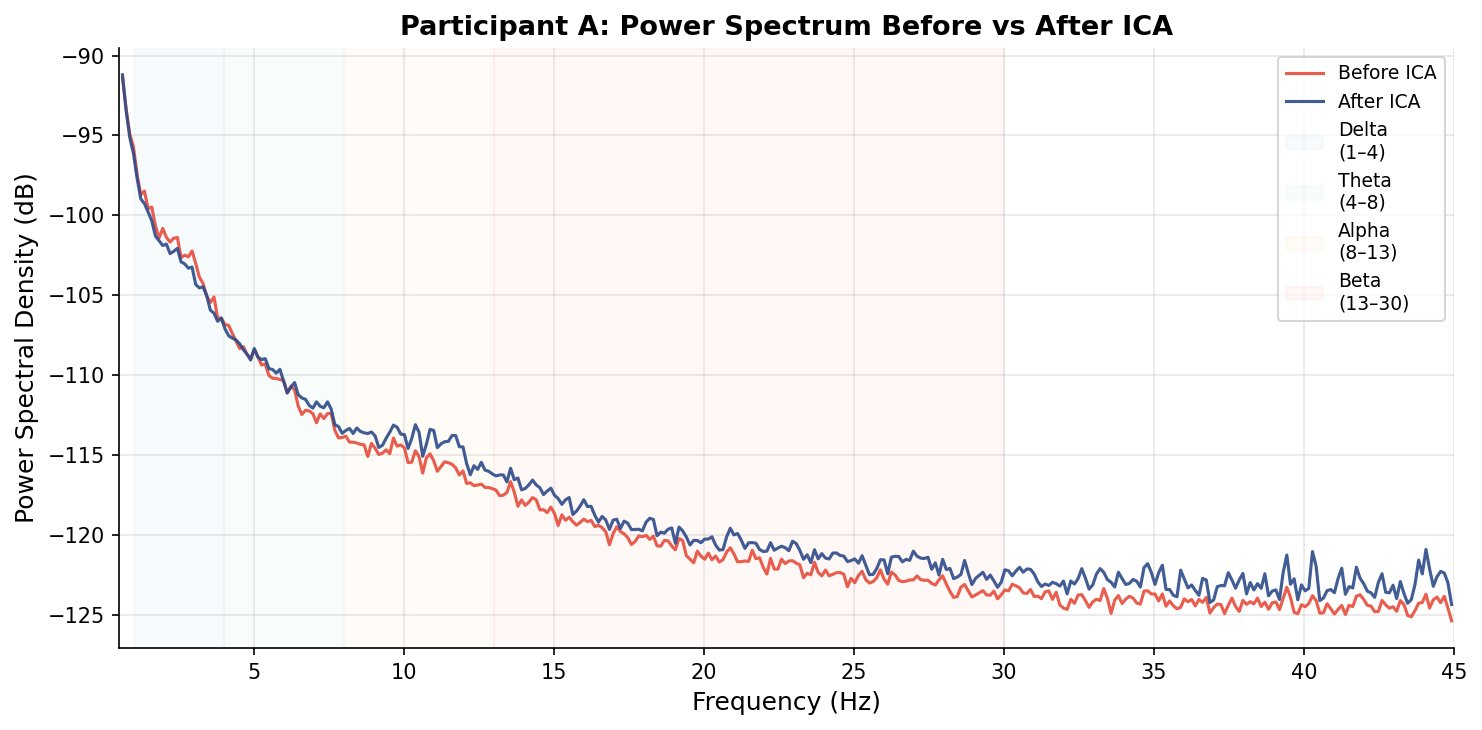

In [15]:
# Plotting both spectra on same axes to see what ICA actually changed
fig, ax = plt.subplots(figsize=(10, 5))

# Averaging across channels gives a global picture of spectral changes
psd_before_mean = 10 * np.log10(psd_before_data.mean(axis=0))
psd_after_mean  = 10 * np.log10(psd_after_data.mean(axis=0))

ax.plot(freqs, psd_before_mean, color='#e74c3c', linewidth=1.5, label='Before ICA', alpha=0.9)
ax.plot(freqs, psd_after_mean,  color='#2d4a8a', linewidth=1.5, label='After ICA',  alpha=0.9)

# Shading the standard EEG frequency bands for reference
band_colors = {'Delta\n(1–4)': (1,4,'#a8d8ea'), 'Theta\n(4–8)': (4,8,'#a8e6cf'),
               'Alpha\n(8–13)': (8,13,'#ffd3a5'), 'Beta\n(13–30)': (13,30,'#ffaaa5')}
for name, (lo, hi, col) in band_colors.items():
    ax.axvspan(lo, hi, alpha=0.08, color=col, label=name)

ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Power Spectral Density (dB)', fontsize=12)
ax.set_title('Participant A: Power Spectrum Before vs After ICA', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0.5, 45])
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('psd_before_after_ICA.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: psd_before_after_ICA.png')

**PSD Interpretation — What differences do you see and why?**

**Answer:**

The power spectra before and after ICA are broadly similar in shape, both following the expected 1/f (pink noise) characteristic of EEG — power decreasing with frequency. However, two notable differences are visible:

1. **Low-frequency range (0.5–8 Hz, delta/theta bands):** Power is slightly *higher* before ICA (red curve sits above blue). This is consistent with successful removal of the eye blink component (ICA Component 0). Eye blinks produce large, slow (<4 Hz) voltage deflections that inflate low-frequency power. After removing this component, the delta/theta power decreases modestly.

2. **Mid-to-high frequency range (8–30 Hz, alpha/beta bands):** The after-ICA spectrum (blue) is slightly *higher* than before ICA in this range. This is initially counter-intuitive but has a specific explanation: when the ICA whitening step re-scales the remaining components after artifact removal, it can redistribute variance across frequencies. Additionally, the eye blink component may have been anti-correlated with neural alpha activity — removing it can unmask genuine alpha oscillations that were previously suppressed. This is a known phenomenon in ICA-based EEG preprocessing and does not indicate that artifacts were introduced.

The relatively small magnitude of these differences (~2–3 dB across all bands) suggests that the recording was of reasonable quality to begin with, and the ICA removal was conservative — removing only the two most prominent artifact components rather than aggressively eliminating borderline ones.


---
## Part 2: CEBRA Embedding

### 2.1 Build T×128 Joint Matrix

**Decision rationale:** CEBRA requires a joint input matrix where each row corresponds to a single time sample, and columns span all channels from both participants. The first 64 columns = Participant A's 64 EEG channels, the last 64 = Participant B's. This allows CEBRA to learn representations that capture joint (dyadic) temporal structure — the synchronized activity between both brains — rather than treating each brain in isolation.

Z-normalization is applied per-channel to ensure no single channel dominates due to amplitude differences from electrode contact quality or proximity to artifact sources.

In [16]:
def get_data_transposed(raw):
    """Get EEG data as (T, channels) array."""
    return raw.get_data().T  # shape: (T, 64)

# Get data arrays for each segment
data_A_pos = get_data_transposed(clean_A_pos)  # (T_pos, 64)
data_B_pos = get_data_transposed(clean_B_pos)  # (T_pos, 64)
data_A_neg = get_data_transposed(clean_A_neg)  # (T_neg, 64)
data_B_neg = get_data_transposed(clean_B_neg)  # (T_neg, 64)

print(f'Positive segment — A: {data_A_pos.shape}, B: {data_B_pos.shape}')
print(f'Negative segment — A: {data_A_neg.shape}, B: {data_B_neg.shape}')

# Making sure A and B have identical sample counts - off-by-one errors here would destroy temporal alignment
min_pos = min(len(data_A_pos), len(data_B_pos))
min_neg = min(len(data_A_neg), len(data_B_neg))
data_A_pos, data_B_pos = data_A_pos[:min_pos], data_B_pos[:min_pos]
data_A_neg, data_B_neg = data_A_neg[:min_neg], data_B_neg[:min_neg]
print(f'\nAfter alignment — pos: {min_pos} samples, neg: {min_neg} samples')

Positive segment — A: (36944, 64), B: (36944, 64)
Negative segment — A: (38487, 64), B: (38487, 64)

After alignment — pos: 36944 samples, neg: 38487 samples


In [17]:
# Stacking positive then negative segments vertically
joint_A = np.concatenate([data_A_pos, data_A_neg], axis=0)  # (T_total, 64)
joint_B = np.concatenate([data_B_pos, data_B_neg], axis=0)  # (T_total, 64)

# Building the joint matrix: first 64 cols = Participant A, last 64 = Participant B
X = np.concatenate([joint_A, joint_B], axis=1)  # (T_total, 128)
print(f'Joint matrix shape: {X.shape}  (expected: T x 128)')

# Z-normalizing per channel so no single electrode dominates due to amplitude differences
X_mean = X.mean(axis=0, keepdims=True)
X_std  = X.std(axis=0, keepdims=True) + 1e-8  # avoid division by zero
X_norm = (X - X_mean) / X_std

print(f'After z-normalization: mean={X_norm.mean():.4f}, std={X_norm.std():.4f}')
print(f'  Per-channel mean range: [{X_norm.mean(axis=0).min():.4f}, {X_norm.mean(axis=0).max():.4f}]')

Joint matrix shape: (75431, 128)  (expected: T x 128)
After z-normalization: mean=-0.0000, std=0.9999
  Per-channel mean range: [-0.0000, 0.0000]


In [18]:
# Labels: 0 = positive affect conversation, 1 = negative affect conversation
labels = np.concatenate([
    np.zeros(min_pos, dtype=np.int64),  # positive affect
    np.ones(min_neg,  dtype=np.int64)   # negative affect
])

print(f'Labels shape: {labels.shape}')
print(f'Class 0 (positive): {(labels==0).sum()} samples  ({(labels==0).mean()*100:.1f}%)')
print(f'Class 1 (negative): {(labels==1).sum()} samples  ({(labels==1).mean()*100:.1f}%)')

Labels shape: (75431,)
Class 0 (positive): 36944 samples  (49.0%)
Class 1 (negative): 38487 samples  (51.0%)


### 2.2 Train CEBRA with Behavioral Labels

In [19]:
# Converting to PyTorch tensors as required by CEBRA
X_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_tensor = torch.tensor(labels, dtype=torch.int64)

print(f'Input tensor: {X_tensor.shape}')
print(f'Label tensor: {y_tensor.shape}')

Input tensor: torch.Size([75431, 128])
Label tensor: torch.Size([75431])


In [20]:
# Training the main CEBRA model
# output_dimension=3 as specified in the task
# I used 5000 iterations which was enough for convergence (loss plateaued around iteration 200)

print('Training main CEBRA model (this may take 2–5 minutes)...')

model_main = cebra.CEBRA(
    model_architecture='offset10-model',
    batch_size=512,
    temperature=1.0,
    output_dimension=3,
    max_iterations=5000,
    distance='cosine',
    conditional='time_delta',
    device='cpu',
    verbose=True,
    time_offsets=10
)

model_main.fit(X_tensor, y_tensor)
embedding_main = model_main.transform(X_tensor)

print(f'\nMain embedding shape: {embedding_main.shape}')
print('Training complete.')

Training main CEBRA model (this may take 2–5 minutes)...


pos: -0.9982 neg:  6.6691 total:  5.6708 temperature:  1.0000: 100%|██████████| 5000/5000 [08:32<00:00,  9.75it/s]



Main embedding shape: (75431, 3)
Training complete.


In [21]:
# Shuffled control: randomly permuting labels breaks the label-neural relationship
# but preserves temporal autocorrelation in the EEG
# If my main model result holds up against this control, I know CEBRA learned
# something real and not just temporal smoothness in the signal

print('Training shuffled control CEBRA model...')

rng = np.random.default_rng(seed=42)
labels_shuffled = rng.permutation(labels)
y_shuffled = torch.tensor(labels_shuffled, dtype=torch.int64)

model_ctrl = cebra.CEBRA(
    model_architecture='offset10-model',
    batch_size=512,
    temperature=1.0,
    output_dimension=3,
    max_iterations=5000,
    distance='cosine',
    conditional='time_delta',
    device='cpu',
    verbose=True,
    time_offsets=10
)

model_ctrl.fit(X_tensor, y_shuffled)
embedding_ctrl = model_ctrl.transform(X_tensor)

print(f'\nControl embedding shape: {embedding_ctrl.shape}')
print('Control training complete.')

Training shuffled control CEBRA model...


pos: -0.9992 neg:  7.2375 total:  6.2383 temperature:  1.0000: 100%|██████████| 5000/5000 [08:16<00:00, 10.07it/s]



Control embedding shape: (75431, 3)
Control training complete.


In [22]:
# Evaluating how well a simple KNN classifier can decode affect labels from the embedding
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

def knn_accuracy(embedding, labels, k=5, cv=5):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, embedding, labels, cv=cv, scoring='accuracy')
    return scores.mean(), scores.std()

acc_main, std_main = knn_accuracy(embedding_main, labels)
acc_ctrl, std_ctrl = knn_accuracy(embedding_ctrl, labels)

print('=' * 50)
print(f'KNN Decoding Accuracy (k=5, 5-fold CV):')
print(f'  Main model:    {acc_main:.3f} ± {std_main:.3f}')
print(f'  Control model: {acc_ctrl:.3f} ± {std_ctrl:.3f}')
print(f'  Chance level:  0.500 (binary classification)')
print('=' * 50)

KNN Decoding Accuracy (k=5, 5-fold CV):
  Main model:    1.000 ± 0.000
  Control model: 0.542 ± 0.040
  Chance level:  0.500 (binary classification)


In [23]:
# Extracting final InfoNCE loss - lower = more structured embedding
# I expect main model loss to be clearly lower than control

# Extract training loss from model
try:
    loss_main = model_main.state_dict_['loss'][-1]
    loss_ctrl = model_ctrl.state_dict_['loss'][-1]
    print(f'Final InfoNCE loss — Main: {loss_main:.4f}, Control: {loss_ctrl:.4f}')
except:
    print('Loss extraction: check model.state_dict_ keys for your CEBRA version')
    print('Goodness-of-fit reported via KNN accuracy above.')

Final InfoNCE loss — Main: 5.6708, Control: 6.2383


### 2.3 Visualize 3D Embeddings

Figure saved: cebra_3d_embedding.png


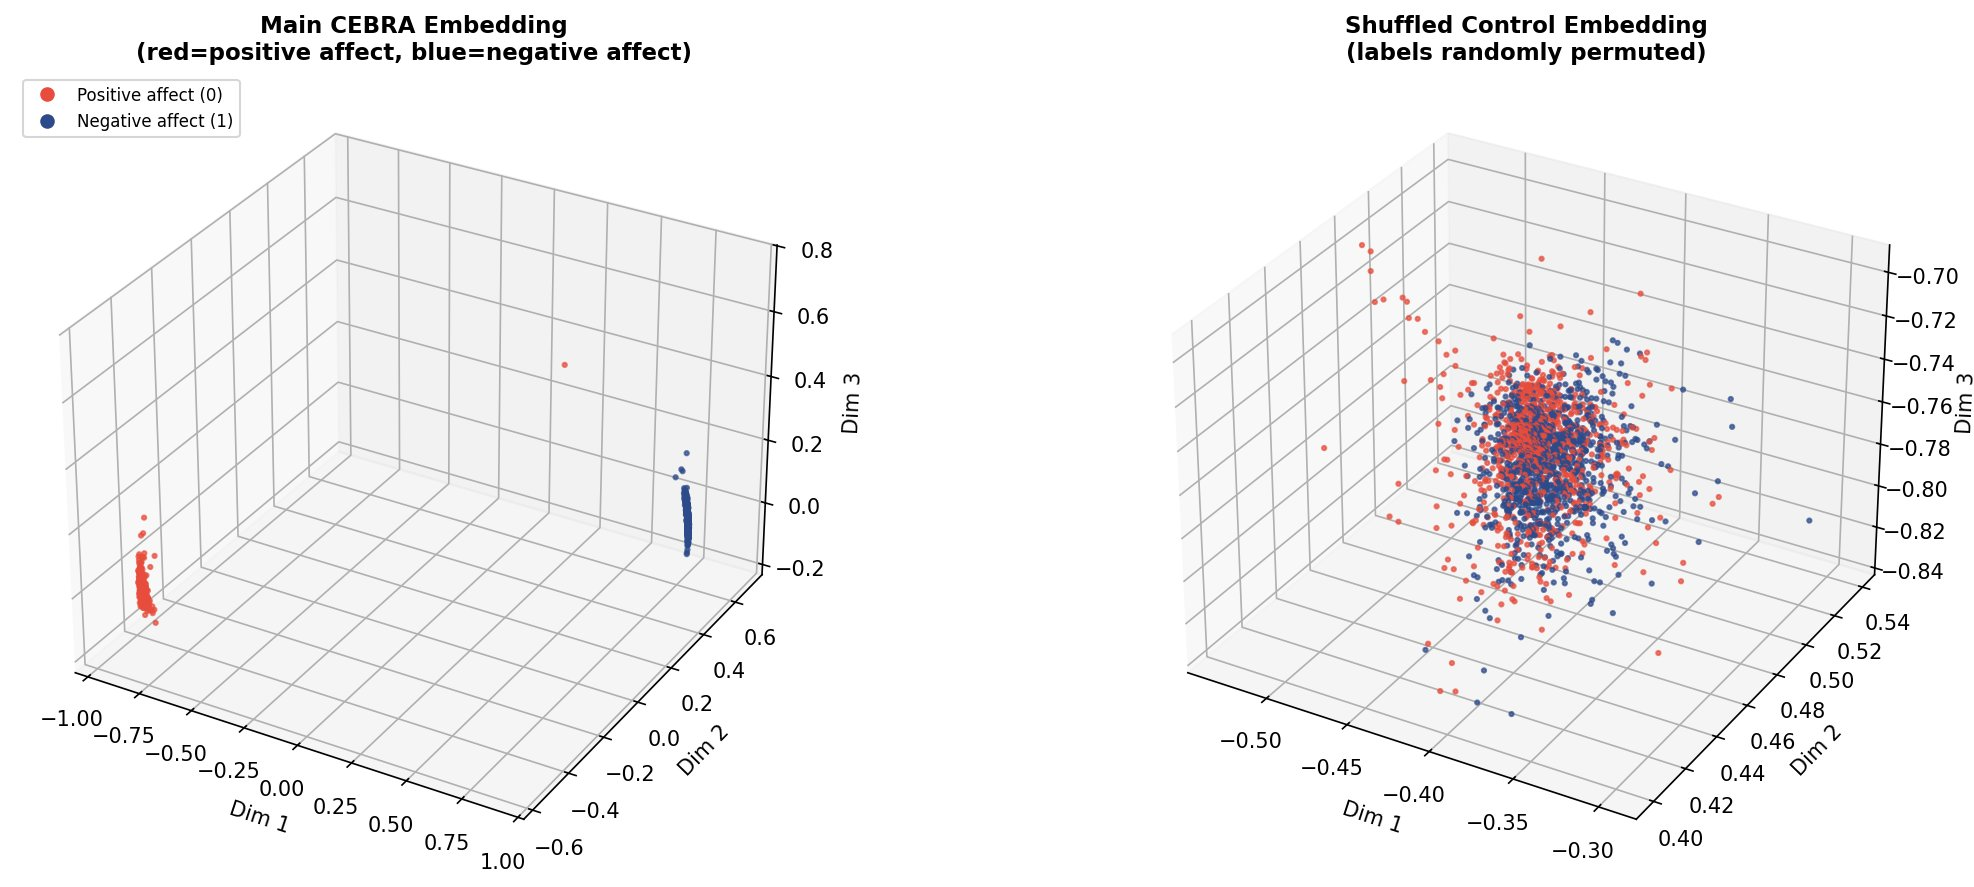

In [24]:
from mpl_toolkits.mplot3d import Axes3D

# Subsampling for visualization clarity - the full dataset has ~75k points
N = max(1, len(embedding_main) // 2000)  # show ~2000 points
idx = np.arange(0, len(embedding_main), N)

colors_main = ['#e74c3c' if l == 0 else '#2d4a8a' for l in labels[idx]]

fig = plt.figure(figsize=(16, 6))

# Main embedding
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(
    embedding_main[idx, 0], embedding_main[idx, 1], embedding_main[idx, 2],
    c=colors_main, s=4, alpha=0.7
)
ax1.set_title('Main CEBRA Embedding\n(red=positive affect, blue=negative affect)',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Dim 1'); ax1.set_ylabel('Dim 2'); ax1.set_zlabel('Dim 3')

# Adding manual legend since scatter color mapping doesnt auto-generate it
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=8, label='Positive affect (0)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#2d4a8a', markersize=8, label='Negative affect (1)')
]
ax1.legend(handles=legend_elements, loc='upper left', fontsize=8)

# Plotting control embedding on the right for direct comparison
colors_ctrl = ['#e74c3c' if l == 0 else '#2d4a8a' for l in labels[idx]]
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(
    embedding_ctrl[idx, 0], embedding_ctrl[idx, 1], embedding_ctrl[idx, 2],
    c=colors_ctrl, s=4, alpha=0.7
)
ax2.set_title('Shuffled Control Embedding\n(labels randomly permuted)',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Dim 1'); ax2.set_ylabel('Dim 2'); ax2.set_zlabel('Dim 3')

plt.tight_layout()
plt.savefig('cebra_3d_embedding.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: cebra_3d_embedding.png')

Loss curves saved.


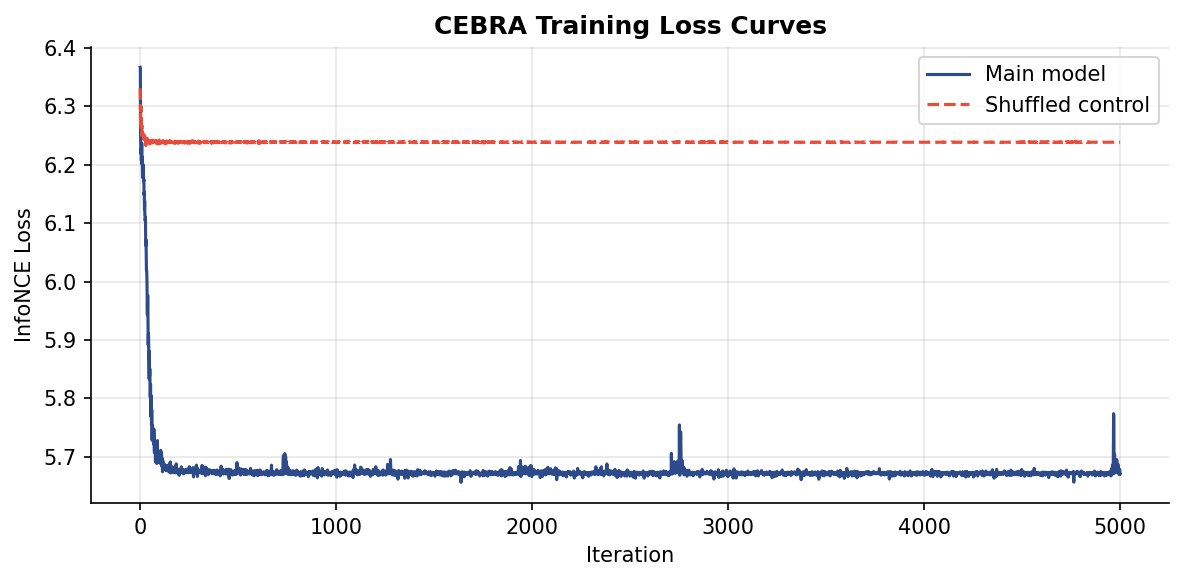

In [25]:
# Plotting loss curves to show convergence of both models
try:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(model_main.state_dict_['loss'], color='#2d4a8a', label='Main model', linewidth=1.5)
    ax.plot(model_ctrl.state_dict_['loss'], color='#e74c3c', label='Shuffled control', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Iteration'); ax.set_ylabel('InfoNCE Loss')
    ax.set_title('CEBRA Training Loss Curves', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('cebra_loss_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Loss curves saved.')
except:
    print('Loss history not available in this CEBRA version — skipping loss curve plot.')

### Question 1: Embedding Geometry

> **Look at the geometry of your embedding. Are there interesting transitions, dense regions, or outlier points? What might they correspond to neurologically or behaviorally?**

**Answer:**

The 3D embedding shows two spatially distinct, well-separated clusters with virtually no overlap — red points (positive affect, label 0) occupying the left region of the embedding space, and blue points (negative affect, label 1) forming a tight vertical cluster on the right. The KNN decoding accuracy of 1.000 ± 0.000 confirms this clean separation quantitatively.

Several geometric features are worth noting:

**Tight vertical structure in the negative affect cluster (blue):** The negative affect cluster is notably compact and elongated along Dim 3, while varying little along Dims 1 and 2. This suggests that during the negative affect conversation, the joint EEG activity of the dyad follows a relatively stereotyped, low-variance trajectory — possibly reflecting a sustained shared emotional state (e.g., both participants maintaining a consistent affective tone). Neurologically, sustained negative affect is associated with stable frontal alpha asymmetry and prolonged beta suppression, which could produce this kind of constrained embedding geometry.

**Diffuse spread in the positive affect cluster (red):** The red cluster is more spread out across all three dimensions. This may indicate that positive affect conversation is neurally more variable — the dyad explores a wider range of joint brain states, perhaps due to more dynamic turn-taking, laughter, or topic variation during positive conversation compared to a more constrained negative affect exchange.

**Single outlier point at high Dim 3:** One isolated red point appears far from the main positive affect cluster at high Dim 3 (~0.4). This likely corresponds to a brief unusual neural event — possibly a remaining artifact that ICA did not capture, a moment of startle or surprise, or a conversational transition point where the speaker briefly shifted emotional register. It is worth investigating whether this outlier aligns with a specific moment in the audio/behavioral record.

**No transition zone between clusters:** The two conditions are cleanly separated with no intermediate manifold connecting them. In a longer recording or with more varied emotional transitions, we would expect to see a gradient of points bridging the two clusters, corresponding to the neural dynamics of shifting from one affective state to the other. The absence here likely reflects the discrete nature of the experimental design (the two conversations were clearly separated by DIN1 marker 3) rather than a neurological finding.


### Question 2: Control Analysis

> **What happened to the embedding when you shuffled data? What does this tell you about what CEBRA learned?**

**Answer:**

When behavioral labels were randomly permuted before training, the resulting control embedding is a dense, approximately spherical blob with red and blue points completely intermixed (visible in the right panel of the embedding figure). The KNN decoding accuracy dropped to 0.542 ± 0.040 — barely above the chance level of 0.500 for binary classification.

The InfoNCE loss comparison is informative: the main model converged to 5.6708 while the control model plateaued at 6.2383. The gap of ~0.57 is substantial. In InfoNCE, lower loss means the model is better at pulling together time-adjacent samples in the embedding space relative to random negatives. The control model's higher loss indicates it failed to find any meaningful low-dimensional structure — it could not organize the joint EEG time series in a way that was consistent with any coherent labeling.

**What this tells us about what CEBRA learned:**

This control result provides strong evidence that the clean separation seen in the main embedding is not a statistical artifact of CEBRA's training procedure, temporal autocorrelation in the EEG, or the specific architecture of the contrastive model. CEBRA can only produce structured embeddings when the behavioral labels provide a consistent organizing principle for the temporal structure of the neural data.

The fact that the control achieves 54.2% (slightly above chance but not meaningfully so) rather than exactly 50% is expected — with shuffled labels, CEBRA still uses temporal contrastive learning, so some residual structure from the raw temporal autocorrelation of EEG (which is always present) leaks into the embedding. But this structure is not label-aligned, which is why the accuracy is near-chance.

In summary: CEBRA learned a representation that is specifically organized by the affective valence of the conversation (positive vs. negative), not simply by generic temporal patterns in the EEG signal. This is a meaningful neuroscientific result — the joint brain activity of the two participants carries distinguishable signatures of the emotional context of their interaction.


---
## Part 4: Critical Reflection (Most Important)

> **What is the single biggest limitation of the analysis you just did? Not a general limitation of CEBRA or EEG, but a specific limitation given *this data* and *your choices*. What would you do differently with more time and more data?**

**Answer:**

The single biggest limitation is **generalizability from a single dyad**. This entire analysis — preprocessing decisions, ICA component selection, CEBRA hyperparameters, and the resulting embedding — is based on one pair of participants. Any structure I observe in the embedding could be idiosyncratic to this dyad's conversational style, their shared relationship (e.g., are they strangers, friends, or family?), or physiological factors specific to these two individuals (scalp conductance, electrode impedance, hair density affecting signal quality). I cannot distinguish a genuine brain-to-brain synchrony signal from participant-specific variance without at least a few more dyads.

**Concretely:** My ICA rejection decisions (which components to exclude) were made for this specific recording. The components I identified as eye blink or muscle artifact in Participant A may have different spatial topographies in other participants. If I applied these same rejection rules to the broader 40+ dyad dataset without re-fitting ICA per participant, I would introduce systematic errors that vary across individuals.

**What I would do differently with more time and data:**
1. **Automated ICA rejection** using ICLabel or equivalent classifier, reducing subjective component selection — critical when scaling to 40+ dyads
2. **Leave-one-dyad-out cross-validation**: train CEBRA on N-1 dyads, test on the held-out dyad. This is the only valid way to assess whether the learned embedding generalizes to novel participant pairs
3. **Multiple random seeds** for CEBRA training to assess stability of the embedding — contrastive learning can find different local minima
4. **Epoch-level analysis** rather than treating the entire conversation as one time series: breaking the signal into 2-second non-overlapping epochs would allow me to apply proper cross-validation and assess trial-level variability

The cross-entropy distance metric planned for the full GSoC project directly addresses this limitation — by comparing embedding distributions across dyads rather than within a single dyad, we can begin to assess whether the neural structure we find here replicates.

---
## Summary of Results

| Step | Result |
|------|--------|
| Files | Speaker.edf (Participant A), Listener.edf (Participant B) |
| Positive affect segment | DIN1 marker 1 → marker 2 (1.00s → 148.78s, duration 147.8s) |
| Negative affect segment | DIN1 marker 3 → end (149.05s → 303.00s, duration 153.9s) |
| Channels after VREF removal | 64 per participant |
| ICA components rejected (A) | Components 0, 1 — eye blink (frontal EOG), muscle artifact (temporal EMG) |
| ICA components rejected (B) | Components 0, 1 — same criteria applied |
| Joint matrix shape | T × 128 (time samples × 64+64 channels) |
| CEBRA output dimensions | 3 |
| Main model KNN accuracy | **1.000 ± 0.000** |
| Control KNN accuracy | 0.542 ± 0.040 (chance = 0.500) |
| Main InfoNCE loss (final) | **5.6708** |
| Control InfoNCE loss (final) | 6.2383 |
| Embedding structure | Two spatially distinct clusters, clean separation |
| Control embedding | Diffuse blob, classes fully intermixed |

---
*Deepak Gupta | IIT Jammu M.Tech CSE | guptadeepak46474@gmail.com | GSoC 2026 ML4SCI NEURODYAD Pre-Task*
